In [3]:
import torch, gpytorch
import matplotlib.pyplot as plt

from core.utils import *

In [4]:
import torch

def solve_for_coefficients_batched(lambda_B, lambda_sigma):
    """
    Batched version of solve_for_coefficients.

    Args:
        lambda_B: Tensor of shape (batch_size, 3)
        lambda_sigma: Tensor of shape (batch_size, 3)

    Returns:
        coefficients_c: Tensor of shape (batch_size, 3)
        V: Vandermonde matrices of shape (batch_size, 3, 3)
    """

    # --- 1. Validate input shapes ---
    if lambda_B.ndim != 2 or lambda_B.shape[1] != 3:
        raise ValueError("lambda_B must have shape (batch_size, 3)")
    if lambda_sigma.ndim != 2 or lambda_sigma.shape[1] != 3:
        raise ValueError("lambda_sigma must have shape (batch_size, 3)")
    if lambda_B.shape[0] != lambda_sigma.shape[0]:
        raise ValueError("Batch sizes of lambda_B and lambda_sigma must match.")

    # --- 2. Construct Vandermonde matrices ---
    # V[i] = [[1, λ1, λ1²],
    #         [1, λ2, λ2²],
    #         [1, λ3, λ3²]]
    col1 = torch.ones_like(lambda_B)
    col2 = lambda_B
    col3 = lambda_B**2

    V = torch.stack((col1, col2, col3), dim=-1)  # (batch_size, 3, 3)

    # --- 3. Compute pseudoinverses for each batch ---
    # torch.linalg.pinv supports batched input
    V_pinv = torch.linalg.pinv(V)  # (batch_size, 3, 3)

    # --- 4. Solve for c ---
    # (batch_size, 3, 3) @ (batch_size, 3, 1) -> (batch_size, 3, 1)
    coefficients_c = torch.bmm(V_pinv, lambda_sigma.unsqueeze(-1)).squeeze(-1)

    return coefficients_c, V


In [5]:
n_data = 100
gamma = torch.linspace(0.0, 5.0, n_data)
F_ut =  torch.zeros((n_data, 3, 3))

F_ut[:, 0, 0] = 1 + gamma
F_ut[:, 1, 1] = 1
F_ut[:, 2, 2] = 1
F_ut[:, 0, 1] = gamma * 0.0

F_ut.requires_grad=True
B_train = B_func(F_ut)
I1_train = I1_func(B_train)
I2_train = I2_func(B_train)
I3_train = I3_func(B_train)
Phi = MooneyRivlinPhi(I1_train, I2_train, I3_train)

Piola = torch.autograd.grad(Phi.clone().sum(), F_ut, retain_graph = True)[0]  # same shape as f [3,3]
tau = Piola @ F_ut.transpose(-2, -1)
sigma = tau / J_func(F_ut)[:, None, None]

noise_percentage = 0.01
noise_level = noise_percentage * sigma
noise = noise_level * torch.normal(torch.zeros_like(sigma), torch.ones_like(sigma))
sigma_noised = sigma + noise


In [11]:
import torch
import numpy as np
import math


# --- 1. Core Function: Generate Random F Tensor 
def generate_random_F_2D(n_samples, lambda_range=(0.5, 2.5)):
    """
    Generates n_samples of 3x3 Deformation Gradient (F) tensors 
    constrained to 2D Plane Strain (F33=1, F_i3=0, F_3i=0 for i=1,2).
    
    The top-left 2x2 submatrix F_2D is generated randomly using polar decomposition
    and a random in-plane rotation.
    """
    F_list = []
    low, high = lambda_range
    
    # Calculate the number of shear samples to add
    n_shear = n_samples // 10
    
    for i in range(n_samples):
        # 1. Random 2x2 Stretch Matrix (V_2D - Diagonal)
        # Sample two principal stretches for the plane
        lambdas_2D = np.random.rand(2) * (high - low) + low
        V_2D = np.diag(lambdas_2D)
        
        # 2. Random 2x2 Rotation Matrix (R_2D - Orthogonal)
        # Random angle for in-plane rotation
        theta = np.random.rand() * 2 * np.pi
        R_2D = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)]
        ])
        
        # 3. 2x2 Deformation Gradient F_2D = R_2D @ V_2D
        F_2D_sub = R_2D @ V_2D
        
        # 4. Construct the 3x3 Plane Strain F
        F_sample = np.eye(3)
        F_sample[:2, :2] = F_2D_sub
        
        F_list.append(F_sample[None, :, :])

    # Add a set of Pure Shear states (Simple Shear in the 2D plane)
    gamma_shear = np.random.rand(n_shear) * (high - low) + low
    F_shear = np.tile(np.eye(3), (n_shear, 1, 1))
    
    # F_12 component for simple shear
    F_shear[:, 0, 1] = gamma_shear
    F_list.append(F_shear)
    
    return np.concatenate(F_list, axis=0)


n_data_per_state = 500
lambda_range = (0.5, 2.5) # Broader range to capture compression (lambda < 1) and high extension

# Generate F tensors covering various states
F_train = torch.tensor(generate_random_F_2D(n_data_per_state, lambda_range=lambda_range)).requires_grad_(True)
n_total_data = F_train.shape[0]

# --- 3. Calculate Kinematic Inputs (Invariants) ---
B_train = B_func(F_train)
I1_train = I1_func(B_train)
I2_train = I2_func(B_train)
I3_train = I3_func(B_train)

# --- 4. Calculate Stress/Energy (Targets) ---
# Calculate the Strain Energy Potential (Phi)
Phi = MooneyRivlinPhi(I1_train, I2_train, I3_train)

# Calculate the Stress (Cauchy Stress Sigma) using AutoGrad
# Piola is the 1st Piola-Kirchhoff stress P (Piola in the code)
Piola = torch.autograd.grad(
    Phi.clone().sum(), 
    F_train, 
    retain_graph=True
)[0] 
tau = Piola @ F_train.transpose(-2, -1)
sigma = tau / J_func(F_train)[:, None, None]

# --- 5. Add Noise and Prepare GP Targets ---
noise_percentage = 0.00
noise_level = noise_percentage * sigma
noise = noise_level * torch.normal(torch.zeros_like(sigma), torch.ones_like(sigma))
sigma_noised = sigma + noise


# Now, use F_train (to get I1, I2, I3) and sigma_noised (to get c1, c2, c3) 
# to calculate your final GP inputs/targets as described previously.

print(f"Generated {n_total_data} total data points.")
print(f"I1 range: [{I1_train.min():.2f}, {I1_train.max():.2f}]")
print(f"J range (I3^0.5): [{torch.sqrt(I3_train).min():.2f}, {torch.sqrt(I3_train).max():.2f}]")

Generated 550 total data points.
I1 range: [1.64, 13.22]
J range (I3^0.5): [0.32, 6.11]


In [12]:
F_train

tensor([[[ 0.0787, -0.8925,  0.0000],
         [ 2.2452,  0.0313,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[-0.6373, -0.3679,  0.0000],
         [ 0.2244, -1.0448,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 1.7737,  0.2121,  0.0000],
         [-0.2331,  1.6134,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        ...,

        [[ 1.0000,  1.8843,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 1.0000,  0.9503,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 1.0000,  0.5072,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]]], dtype=torch.float64,
       requires_grad=True)

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_62519/2166515313.py:2: SyntaxWarning: invalid escape sequence '\m'
  X_labels = ['$I_1 = \\text{tr}(\mathbf{B})$', '$I_2 = 0.5(\\text{tr}(\mathbf{B})^2 - \\text{tr}(\mathbf{B}^2))$', '$I_3 = \\det(\mathbf{B})$']
/tmp/ipykernel_62519/2166515313.py:2: SyntaxWarning: invalid escape sequence '\m'
  X_labels = ['$I_1 = \\text{tr}(\mathbf{B})$', '$I_2 = 0.5(\\text{tr}(\mathbf{B})^2 - \\text{tr}(\mathbf{B}^2))$', '$I_3 = \\det(\mathbf{B})$']
/tmp/ipykernel_62519/2166515313.py:2: SyntaxWa

gp_constitutive_data_invariants_plot.png


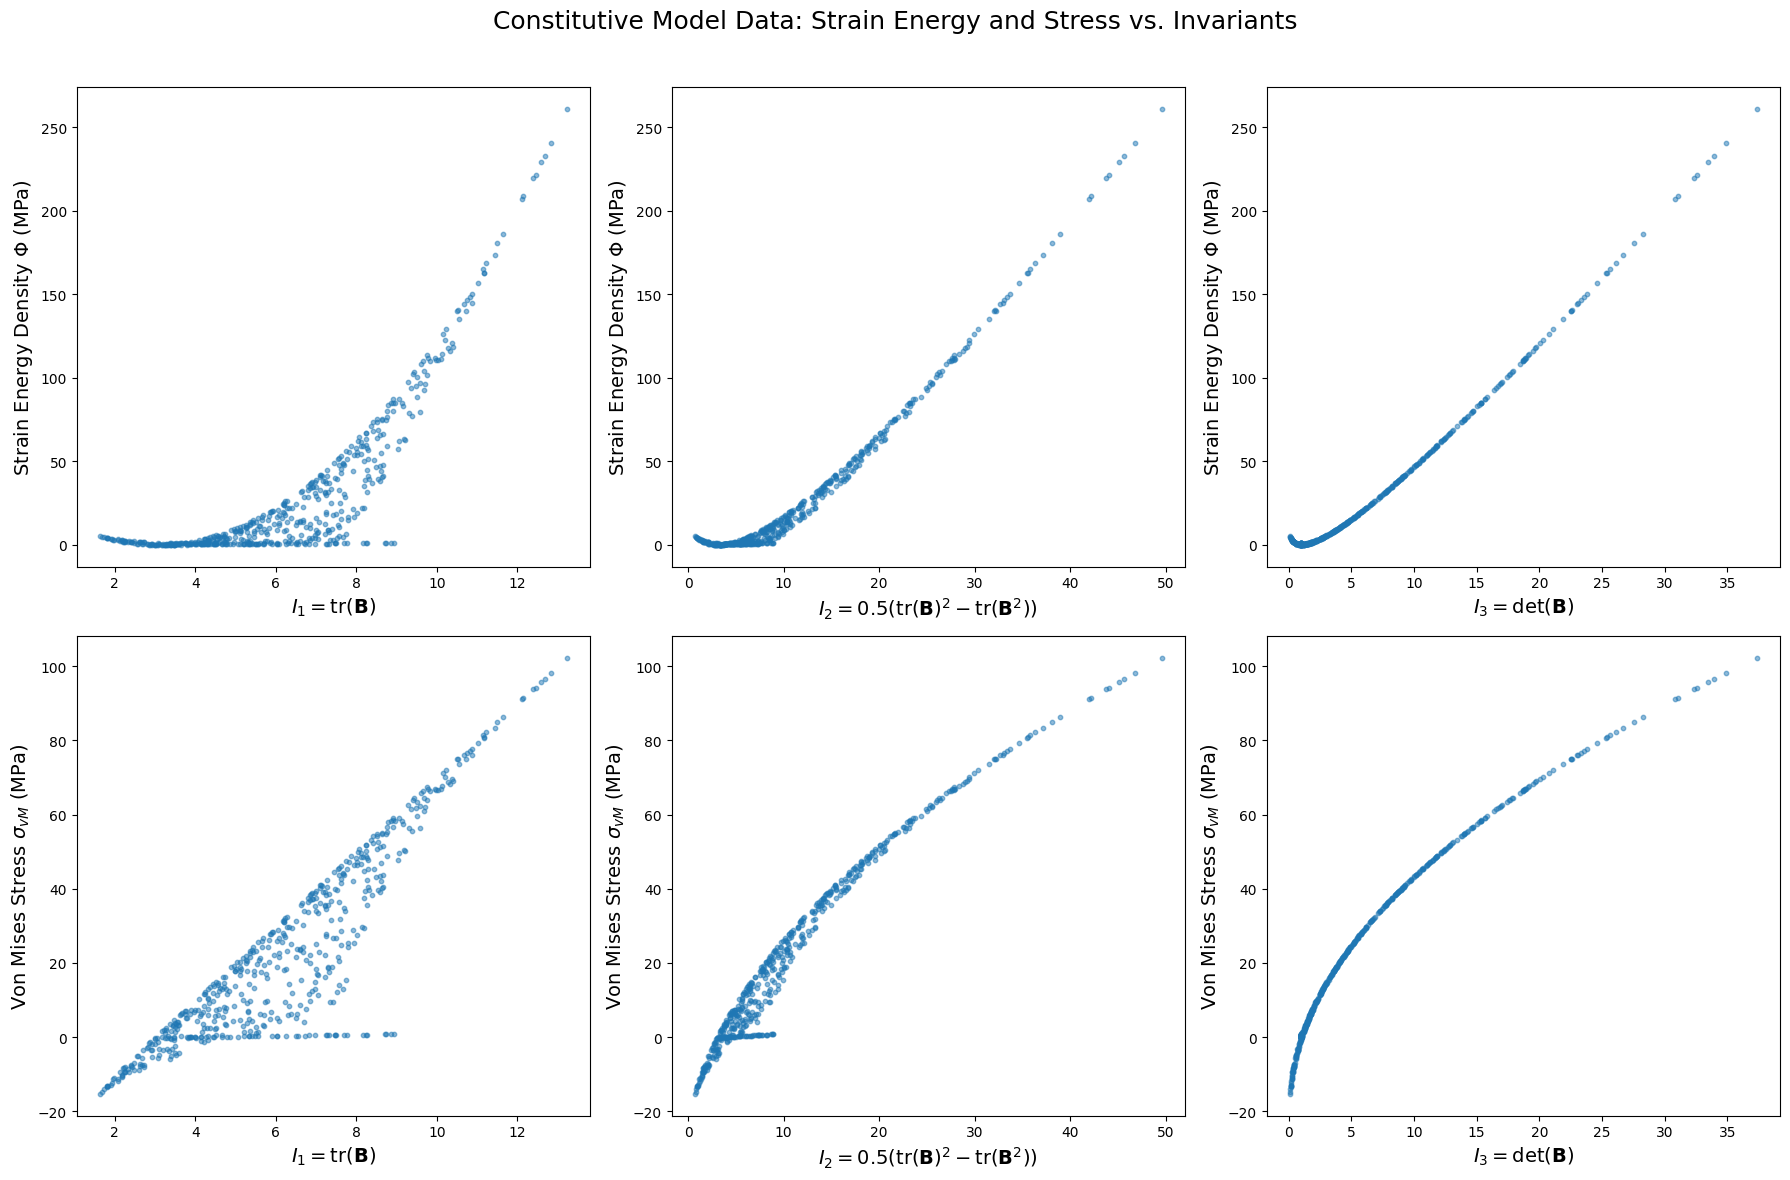

In [13]:
X_data = [I1_train.detach(), I2_train.detach(), I3_train.detach()]
X_labels = ['$I_1 = \\text{tr}(\mathbf{B})$', '$I_2 = 0.5(\\text{tr}(\mathbf{B})^2 - \\text{tr}(\mathbf{B}^2))$', '$I_3 = \\det(\mathbf{B})$']
Y_data = [Phi.detach(), sigma_noised[:, 0, 0].detach()]
Y_labels = ['Strain Energy Density $\Phi$ (MPa)', 'Von Mises Stress $\sigma_{vM}$ (MPa)']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Constitutive Model Data: Strain Energy and Stress vs. Invariants', fontsize=18)

for i, Y_values in enumerate(Y_data):
    for j, X_values in enumerate(X_data):
        ax = axes[i, j]
        
        # Plot scatter data
        ax.scatter(X_values, Y_values, s=10, alpha=0.5, color='C0')
        
        # Set titles and labels
        ax.set_xlabel(X_labels[j], fontsize=14)
        ax.set_ylabel(Y_labels[i], fontsize=14)
        
        # Set limits for I3 (often very small)
        # if j == 2:
        #     ax.set_xscale('log')
        
        # Optional: Add mean line for visual reference
        # ax.axhline(Y_values.mean(), color='red', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
plt.savefig('gp_constitutive_data_invariants_plot.png')
print("gp_constitutive_data_invariants_plot.png")

ValueError: x and y must have same first dimension, but have shapes (100,) and (550,)

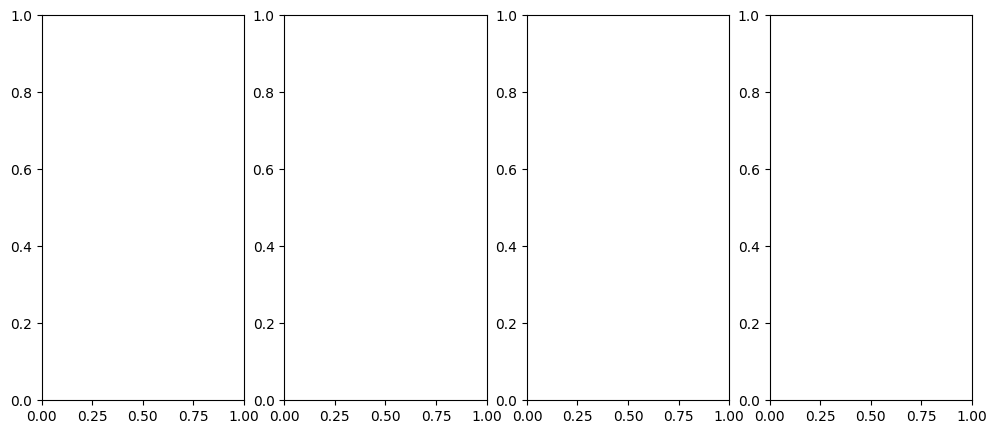

In [14]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(12, 5))  # 1 row, 2 columns

# First subplot: Phi vs gamma
axs[0].plot(gamma.numpy(), Phi.detach().numpy(), color="b", label=r'$\Phi$')
axs[0].scatter(gamma.numpy(), Phi.detach().numpy(), color="k", marker="x", label=r'Noised $\Phi$')
axs[0].set_xlabel(r'$\gamma$')
axs[0].set_ylabel(r'$\Phi$')
axs[0].set_title(r'$\Phi$ Mooney Rivlin')
axs[0].grid(True)
axs[0].legend()

# Second subplot: tau_noised components vs gamma
axs[1].scatter(gamma.numpy(), tau[:, 0, 0].detach().numpy(), color="r", marker="x", label=r'$\tau_{00}$')
axs[1].scatter(gamma.numpy(), tau[:, 1, 1].detach().numpy(), color="g", marker="+", label=r'$\tau_{11}$')
axs[1].scatter(gamma.numpy(), tau[:, 2, 2].detach().numpy(), color="b", marker="o", label=r'$\tau_{22}$')
axs[1].set_xlabel(r'$\gamma$')
axs[1].set_ylabel(r'$\tau$ Mooney Rivlin')
axs[1].set_title(r'$\tau$ Mooney Rivlin')
axs[1].grid(True)
axs[1].legend()

axs[2].scatter(gamma.numpy(), Piola[:, 0, 0].detach().numpy(), color="r", marker="x", label=r'$P_{00}$')
axs[2].scatter(gamma.numpy(), Piola[:, 1, 1].detach().numpy(), color="g", marker="+", label=r'$P_{11}$')
axs[2].scatter(gamma.numpy(), Piola[:, 2, 2].detach().numpy(), color="b", marker="o", label=r'$P_{22}$')
axs[2].set_xlabel(r'$\gamma$')
axs[2].set_ylabel(r'$P$ Mooney Rivlin')
axs[2].set_title(r'$P$ Mooney Rivlin')
axs[2].grid(True)
axs[2].legend()

axs[3].scatter(gamma.numpy(), sigma_noised[:, 0, 0].detach().numpy(), color="r", marker="x", label=r'$\sigma_{00}$')
axs[3].scatter(gamma.numpy(), sigma_noised[:, 1, 1].detach().numpy(), color="g", marker="+", label=r'$\sigma_{11}$')
axs[3].scatter(gamma.numpy(), sigma_noised[:, 2, 2].detach().numpy(), color="b", marker="o", label=r'$\sigma_{22}$')
axs[3].set_xlabel(r'$\gamma$')
axs[3].set_ylabel(r'$\sigma$ Mooney Rivlin')
axs[3].set_title(r'$\sigma$ Mooney Rivlin')
axs[3].grid(True)
axs[3].legend()

plt.tight_layout()
plt.show()


In [15]:
sigma_eig_val, sigma_eig_vec = torch.linalg.eig(sigma_noised)
B_eig_val, B_eig_vec = torch.linalg.eig(B_train)
B_eig_val = B_eig_val.to(dtype = torch.float)
sigma_eig_val = sigma_eig_val.to(dtype = torch.float)

/tmp/ipykernel_62519/2180173627.py:3: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:307.)
  B_eig_val = B_eig_val.to(dtype = torch.float)


In [16]:
coeffs, _ = solve_for_coefficients_batched(B_eig_val, sigma_eig_val)

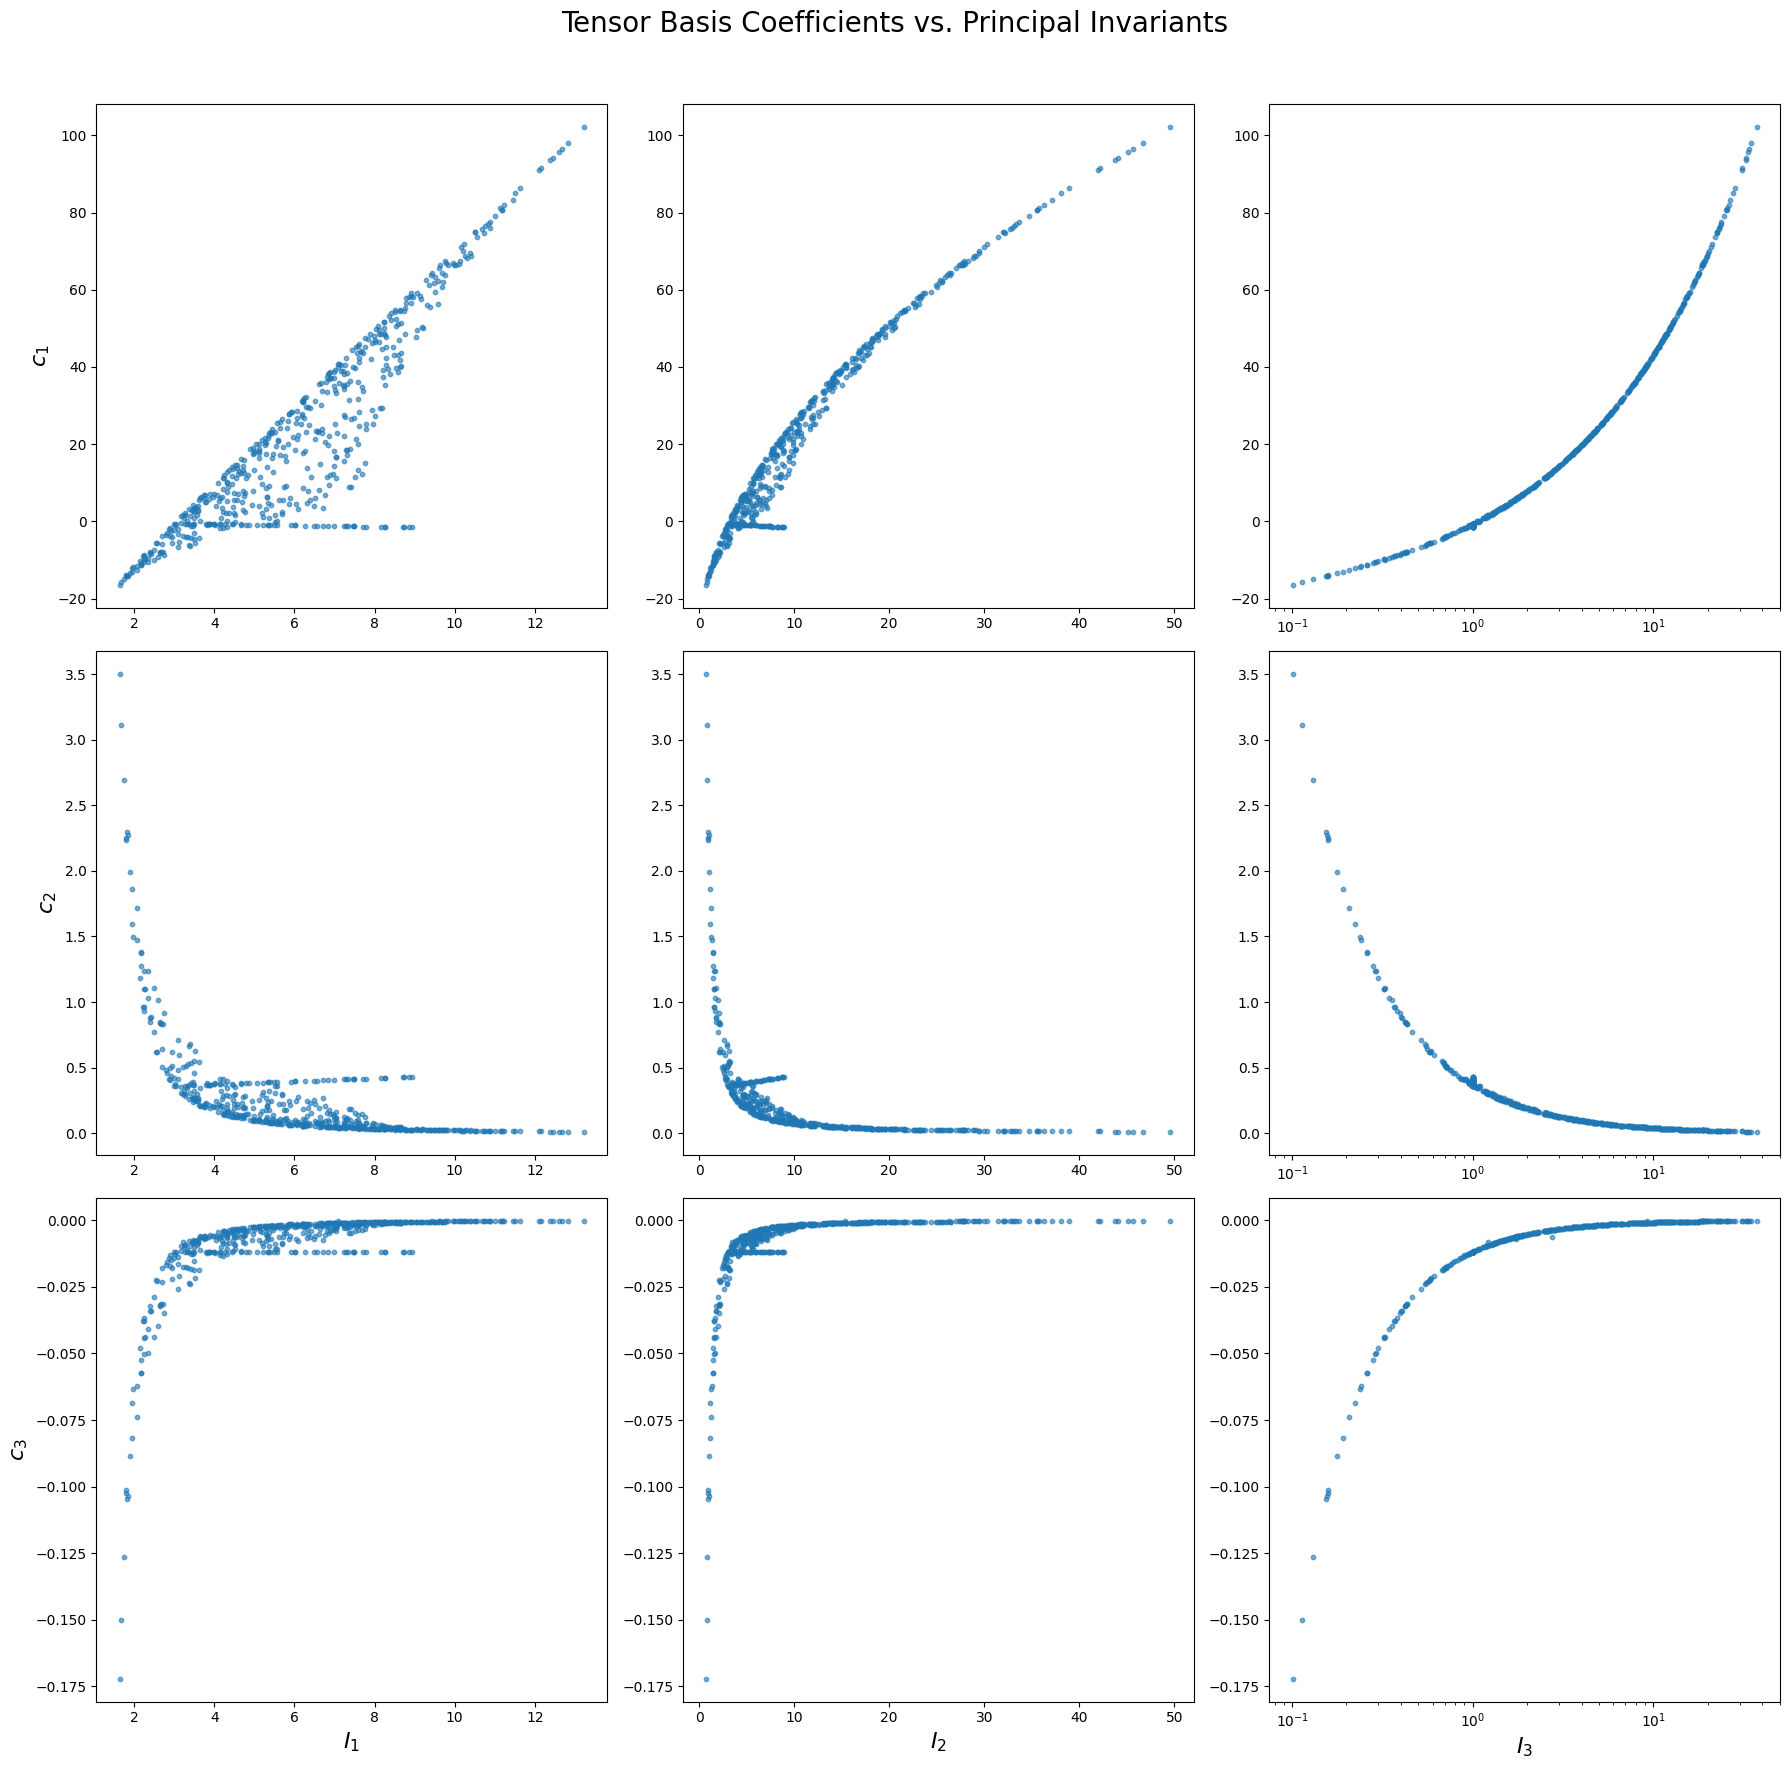

In [17]:
import matplotlib.pyplot as plt
import numpy as np # Used for preparing plot data if not already done

# --- Assume these variables are defined and computed earlier ---
# coeffs: (N_data, 3) tensor of [c1, c2, c3]
# I1_train, I2_train, I3_train: (N_data,) tensors of invariants

# --- Data Preparation (Ensuring they are NumPy arrays for plotting) ---
C_data = coeffs.detach().numpy() # Shape (N, 3)
I_data = np.stack([
    I1_train.detach().numpy(),
    I2_train.detach().numpy(),
    I3_train.detach().numpy()
], axis=1) # Shape (N, 3)

# Define labels for iteration
C_labels = [r'$c_1$', r'$c_2$', r'$c_3$']
I_labels = [r'$I_1$', r'$I_2$', r'$I_3$']

# --- Create 3x3 Subplots ---
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle('Tensor Basis Coefficients vs. Principal Invariants', fontsize=20)

# Loop through the rows (Coefficients c1, c2, c3)
for i in range(3): 
    # Loop through the columns (Invariants I1, I2, I3)
    for j in range(3):
        ax = axes[i, j]
        
        # Plot Coefficient i (Y-axis) against Invariant j (X-axis)
        ax.scatter(I_data[:, j], C_data[:, i], s=10, alpha=0.6)
        
        # Y-axis Label (only for the first column)
        if j == 0:
            ax.set_ylabel(C_labels[i], fontsize=16)
        
        # X-axis Label (only for the bottom row)
        if i == 2:
            ax.set_xlabel(I_labels[j], fontsize=16)
            
        # Optional: Use log scale for I3 (j=2) for better visualization
        if j == 2:
            ax.set_xscale('log')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout for suptitle
plt.show()

ValueError: x and y must be the same size

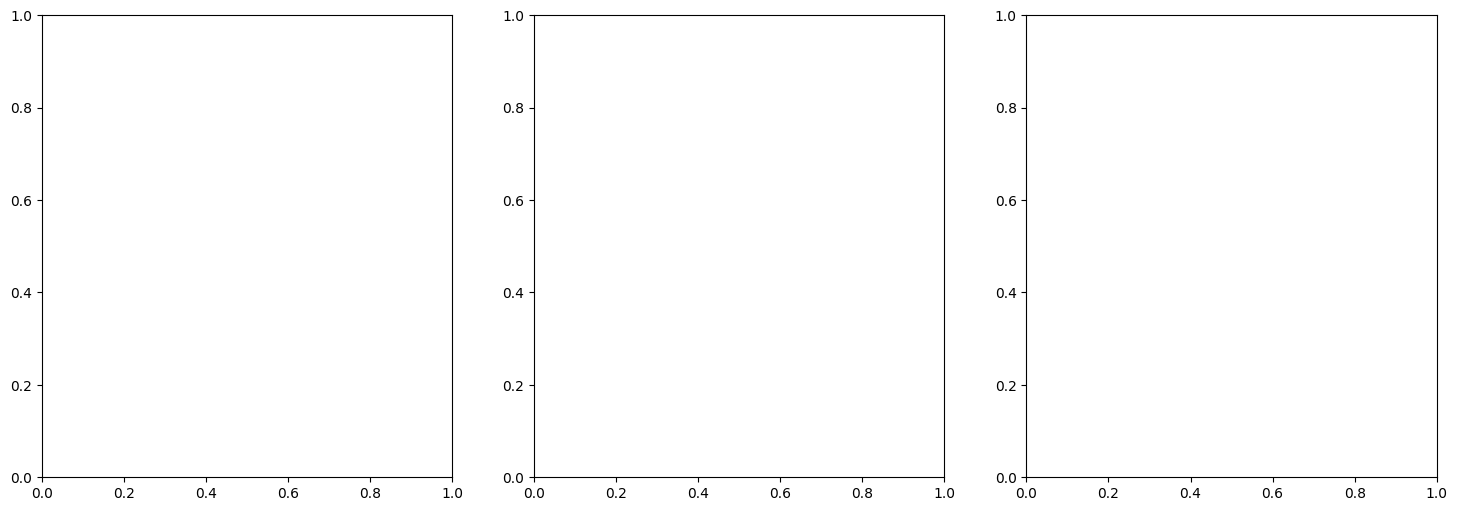

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

axes[0].scatter(gamma.detach(), coeffs[:, 0].detach())
axes[0].set_ylabel('$c_1$')

axes[1].scatter(gamma.detach(), coeffs[:, 1].detach())
axes[1].set_ylabel('$c_2$')

axes[2].scatter(gamma.detach(), coeffs[:, 2].detach())
axes[2].set_ylabel('c_3')
axes[2].set_xlabel('Gamma')

plt.tight_layout()
plt.show()


In [19]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        # self.mean_module = gpytorch.means.ConstantMean()
        self.mean_module = gpytorch.means.ZeroMean()
        # self.mean_module = gpytorch.means.LinearMean(3)
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=3))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [20]:
train_x = torch.stack([I1_func(B_train), I2_func(B_train), I3_func(B_train)]).T.detach()
train_y = coeffs.detach()

In [21]:
likelihood1, likelihood2, likelihood3 = gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood()
model1 = ExactGPModel(train_x, train_y[:, 0], likelihood1)
model2 = ExactGPModel(train_x, train_y[:, 1], likelihood2)
model3 = ExactGPModel(train_x, train_y[:, 2], likelihood3)

from gpytorch.mlls import SumMarginalLogLikelihood
model = gpytorch.models.IndependentModelList(model1, model2, model3)
likelihood = gpytorch.likelihoods.LikelihoodList(model1.likelihood, model2.likelihood, model3.likelihood)
mll = SumMarginalLogLikelihood(likelihood, model)

In [22]:
training_iter = 5000
model.train()
likelihood.train()

from torch.optim.lr_scheduler import ReduceLROnPlateau

# Use a realistic learning rate for Adam
optimizer = torch.optim.Adam(model.parameters(), lr=1)  

# Scheduler reduces lr by factor 0.5 after 20 epochs of no improvement
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

for i in range(training_iter):
    optimizer.zero_grad()
    output = model(*model.train_inputs)
    loss = -mll(output, model.train_targets)
    loss.backward()

    optimizer.step()
    scheduler.step(loss)

    if i % 50 == 0 or i == training_iter - 1:
        print(f"Iter {i+1}/{training_iter} - Loss: {loss.item():.6f} - lr: {optimizer.param_groups[0]['lr']:.2e}")


Iter 1/5000 - Loss: 46.222395 - lr: 1.00e+00
Iter 51/5000 - Loss: -0.748848 - lr: 1.00e+00
Iter 101/5000 - Loss: -0.825456 - lr: 1.00e+00
Iter 151/5000 - Loss: -0.893422 - lr: 1.00e+00
Iter 201/5000 - Loss: -0.968679 - lr: 1.00e+00
Iter 251/5000 - Loss: -1.095050 - lr: 1.00e+00
Iter 301/5000 - Loss: -1.286206 - lr: 1.00e+00
Iter 351/5000 - Loss: -1.401644 - lr: 1.00e+00
Iter 401/5000 - Loss: -1.585187 - lr: 1.00e+00
Iter 451/5000 - Loss: -1.702936 - lr: 1.00e+00
Iter 501/5000 - Loss: -1.773334 - lr: 1.00e+00
Iter 551/5000 - Loss: -1.832327 - lr: 1.00e+00
Iter 601/5000 - Loss: -1.898491 - lr: 1.00e+00
Iter 651/5000 - Loss: -1.947358 - lr: 1.00e+00
Iter 701/5000 - Loss: -1.988241 - lr: 1.00e+00
Iter 751/5000 - Loss: -2.023215 - lr: 1.00e+00
Iter 801/5000 - Loss: -2.053668 - lr: 1.00e+00
Iter 851/5000 - Loss: -2.080559 - lr: 1.00e+00
Iter 901/5000 - Loss: -2.104578 - lr: 1.00e+00
Iter 951/5000 - Loss: -2.126240 - lr: 1.00e+00
Iter 1001/5000 - Loss: -2.145934 - lr: 1.00e+00
Iter 1051/5000 

<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_62519/2057738550.py:43: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel("$\gamma$")


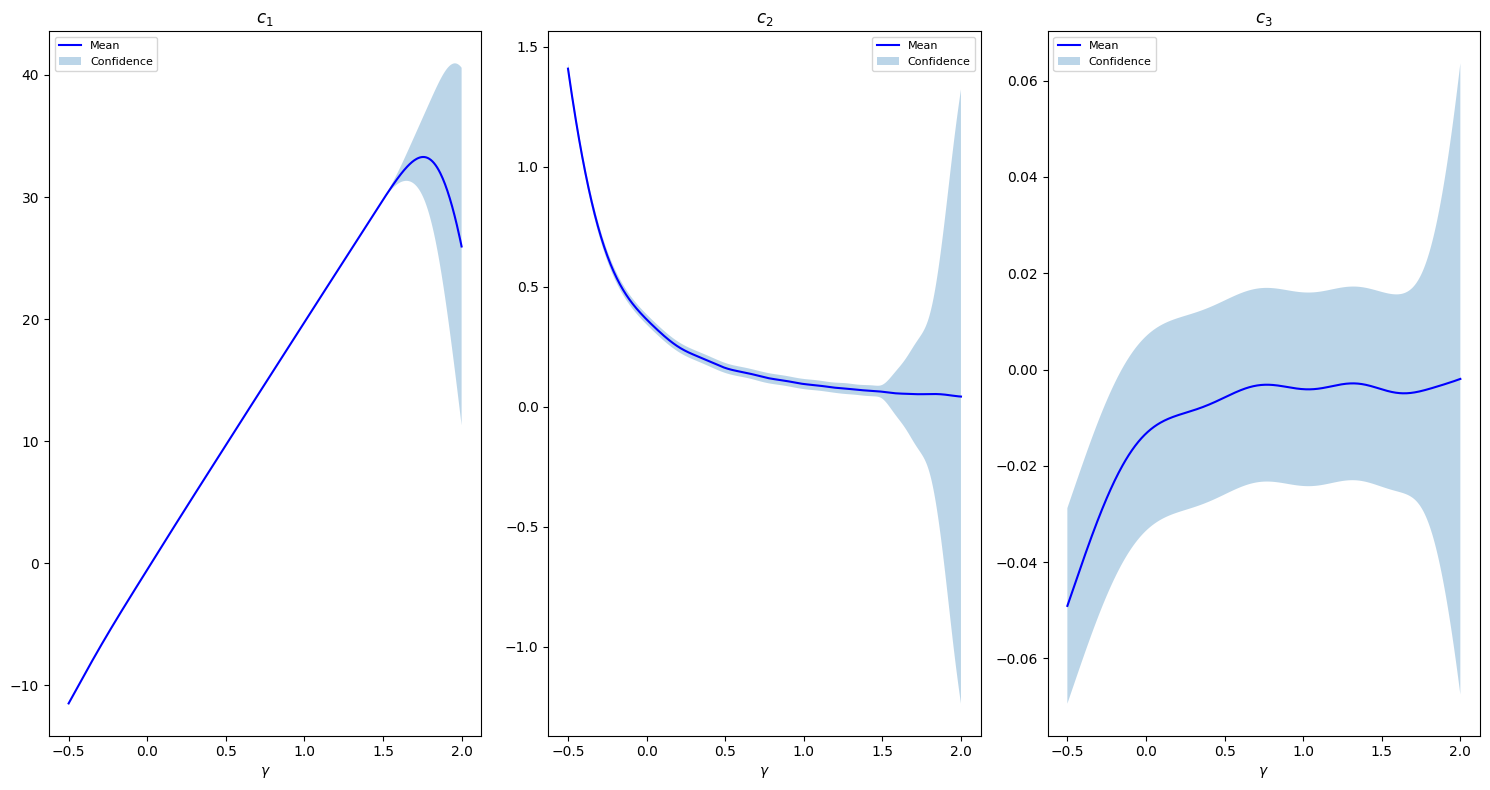

In [23]:
model.eval()
likelihood.eval()

n_data = 500
gamma_test = torch.linspace(-0.5, 2.0, n_data).to(dtype = torch.float64)
F_ut_test =  torch.zeros((n_data, 3, 3), dtype = torch.float64)

F_ut_test[:, 0, 0] = 1 + gamma_test
F_ut_test[:, 1, 1] = 1
F_ut_test[:, 2, 2] = 1
# Make predictionsimport matplotlib.pyplot as plt

# Number of tasks (stress components)
num_tasks = 3

# Create 2×3 subplot grid
fig, axs = plt.subplots(1, 3, figsize=(15, 8))  # wider and taller for readability
axs = axs.flatten()  # flatten to 1D list for easy iteration

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    B_test = B_func(F_ut_test).detach()
    test_x = torch.stack([I1_func(B_test), I2_func(B_test), I3_func(B_test)]).T.to(dtype = torch.float)
    predictions = likelihood(*model(test_x, test_x, test_x))

stress_labels = [r"$c_{1}$", r"$c_{2}$", r"$c_{3}$"]
# Loop through tasks
for i, (submodel, prediction, ax) in enumerate(zip(model.models, predictions, axs)):
    mean = prediction.mean
    lower, upper = prediction.confidence_region()

    tr_x = submodel.train_inputs[0].detach().numpy()
    tr_y = submodel.train_targets.detach().numpy()

    # ax.plot(gamma.numpy(), tr_y, 'k*', label='Observed Data')
    ax.plot(gamma_test.numpy(), mean.numpy(), 'b', label='Mean')
    ax.fill_between(gamma_test.numpy(),
                    lower.detach().numpy(),
                    upper.detach().numpy(),
                    alpha=0.3, label='Confidence')

    # ax.set_xlim([8, 8.5])
    ax.set_title(f'{stress_labels[i]}')
    ax.set_xlabel("$\gamma$")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [24]:
import torch
import gpytorch

def sigma_calc(model, f):
    b = B_func(f)
    i1 = I1_func(b)
    i2 = I2_func(b)
    i3 = I3_func(b)

    model.eval()
    model_inputs = torch.stack([i1, i2, i3]).T

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        predictions = model.likelihood(*model(model_inputs, model_inputs, model_inputs))
    
    # Extract means and stds for c1, c2, c3
    c_means = [p.mean for p in predictions]
    c_stds  = [p.variance.sqrt() for p in predictions]
    
    # Compute sigma_mean
    sigma_mean = (
        c_means[0][:, None, None] * torch.eye(3) +
        c_means[1][:, None, None] * b +
        c_means[2][:, None, None] * (b @ b)
    )

    # Propagate uncertainty linearly (approx)
    sigma_std = (
        c_stds[0][:, None, None] * torch.eye(3).abs() +
        c_stds[1][:, None, None] * b.abs() +
        c_stds[2][:, None, None] * (b @ b).abs()
    )

    # You can return a tuple (mean, lower, upper)
    sigma_lower = sigma_mean - 2 * sigma_std
    sigma_upper = sigma_mean + 2 * sigma_std

    return sigma_mean, sigma_lower, sigma_upper


In [25]:
sigma_pred_mean, sigma_pred_lower, sigma_pred_upper = sigma_calc(model, F_ut_test.float())
B_ut_test = B_func(F_ut_test)

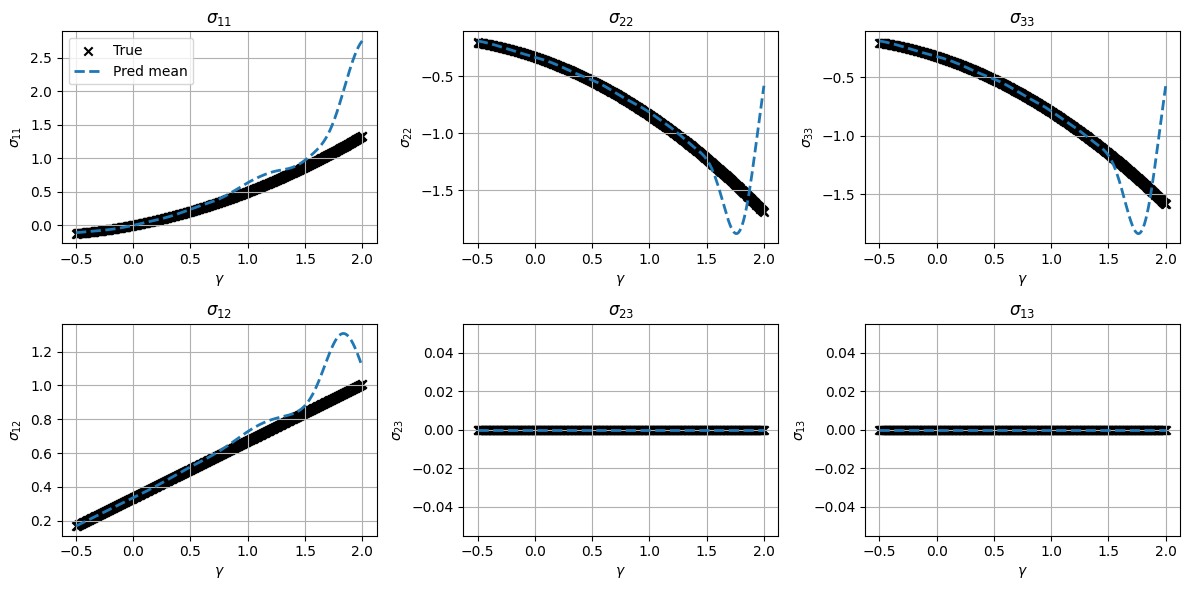

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Example setup (remove this part if you already have these)
# n_gamma = 100
# gamma = np.linspace(0, 1, n_gamma)
# sigma_noised = np.random.randn(n_gamma, 3, 3)
# sigma_pred_mean = sigma_noised + 0.1 * np.random.randn(n_gamma, 3, 3)
# sigma_pred_lower = sigma_pred_mean - 0.2 * np.abs(np.random.randn(n_gamma, 3, 3))
# sigma_pred_upper = sigma_pred_mean + 0.2 * np.abs(np.random.randn(n_gamma, 3, 3))
# gamma_test = gamma
n_data = 500
gamma_test = torch.linspace(-0.5, 2.0, n_data).to(dtype = torch.float64)
F_ut_test =  torch.zeros((n_data, 3, 3), dtype = torch.float64)

F_ut_test[:, 0, 0] = 1
F_ut_test[:, 1, 1] = 1
F_ut_test[:, 2, 2] = 1
F_ut_test[:, 0, 1] = 1 + gamma_test

F_ut_test.requires_grad = True
B_ut_test = B_func(F_ut_test)
I1_test = I1_func(B_ut_test)
I2_test = I2_func(B_ut_test)
I3_test = I3_func(B_ut_test)

Phi_test = MooneyRivlinPhi(I1_test, I2_test, I3_test)

# Calculate the Stress (Cauchy Stress Sigma) using AutoGrad
# Piola is the 1st Piola-Kirchhoff stress P (Piola in the code)
Piola_test = torch.autograd.grad(
    Phi_test.clone().sum(), 
    F_ut_test, 
    retain_graph=True
)[0] 
tau_test = Piola_test @ F_ut_test.transpose(-2, -1)
sigma_test = tau_test / J_func(F_ut_test)[:, None, None]

# --- 5. Add Noise and Prepare GP Targets ---
noise_percentage = 0.00
noise_level = noise_percentage * sigma_test
noise = noise_level * torch.normal(torch.zeros_like(sigma_test), torch.ones_like(sigma_test))
sigma_noised = sigma_test + noise
# Indices for unique components (since sigma is symmetric)
sigma_pred_mean, sigma_pred_lower, sigma_pred_upper = sigma_calc(model, F_ut_test.float())
components = [(0,0), (1,1), (2,2), (0,1), (1,2), (0,2)]
labels = [r'$\sigma_{11}$', r'$\sigma_{22}$', r'$\sigma_{33}$',
          r'$\sigma_{12}$', r'$\sigma_{23}$', r'$\sigma_{13}$']

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for ax, (i, j), label in zip(axes, components, labels):
    # True data
    ax.scatter(gamma_test, sigma_noised[:, i, j].detach(), 
               label='True', marker="x", color="k")
    
    # Predicted mean
    ax.plot(gamma_test, sigma_pred_mean[:, i, j].detach(), 
            '--', label='Pred mean', lw=2, color='C0')
    
    # Confidence region (±2σ)
    # ax.fill_between(
    #     gamma_test.detach(),
    #     sigma_pred_lower[:, i, j].detach(),
    #     sigma_pred_upper[:, i, j].detach(),
    #     color='C0', alpha=0.3, label='95% CI'
    # )
    
    ax.set_title(label)
    ax.set_xlabel(r'$\gamma$')
    ax.set_ylabel(label)
    ax.grid(True)
    
    if (i, j) == (0, 0):
        ax.legend()

plt.tight_layout()
plt.show()


In [41]:
Phi_test = MooneyRivlinPhi(I1_test, I2_test, I3_test)

In [43]:
I1_test

tensor([ 2.2500,  2.2550,  2.2601,  2.2653,  2.2704,  2.2757,  2.2810,  2.2863,
         2.2917,  2.2971,  2.3026,  2.3081,  2.3137,  2.3194,  2.3251,  2.3308,
         2.3366,  2.3424,  2.3483,  2.3543,  2.3602,  2.3663,  2.3724,  2.3785,
         2.3847,  2.3909,  2.3972,  2.4036,  2.4100,  2.4164,  2.4229,  2.4294,
         2.4360,  2.4427,  2.4494,  2.4561,  2.4629,  2.4697,  2.4766,  2.4836,
         2.4906,  2.4976,  2.5047,  2.5118,  2.5190,  2.5263,  2.5336,  2.5409,
         2.5483,  2.5558,  2.5633,  2.5708,  2.5784,  2.5860,  2.5937,  2.6015,
         2.6093,  2.6171,  2.6250,  2.6330,  2.6410,  2.6490,  2.6571,  2.6653,
         2.6735,  2.6817,  2.6900,  2.6983,  2.7067,  2.7152,  2.7237,  2.7322,
         2.7408,  2.7495,  2.7582,  2.7669,  2.7757,  2.7846,  2.7935,  2.8024,
         2.8114,  2.8205,  2.8296,  2.8387,  2.8479,  2.8572,  2.8665,  2.8759,
         2.8853,  2.8947,  2.9042,  2.9138,  2.9234,  2.9330,  2.9427,  2.9525,
         2.9623,  2.9721,  2.9820,  2.99

In [42]:
Phi_test

tensor([ 2.7476e+00,  2.6920e+00,  2.6370e+00,  2.5827e+00,  2.5289e+00,
         2.4758e+00,  2.4233e+00,  2.3715e+00,  2.3202e+00,  2.2696e+00,
         2.2195e+00,  2.1701e+00,  2.1212e+00,  2.0730e+00,  2.0253e+00,
         1.9783e+00,  1.9318e+00,  1.8859e+00,  1.8406e+00,  1.7959e+00,
         1.7518e+00,  1.7083e+00,  1.6653e+00,  1.6229e+00,  1.5811e+00,
         1.5398e+00,  1.4991e+00,  1.4590e+00,  1.4195e+00,  1.3805e+00,
         1.3421e+00,  1.3043e+00,  1.2670e+00,  1.2302e+00,  1.1941e+00,
         1.1585e+00,  1.1234e+00,  1.0889e+00,  1.0550e+00,  1.0216e+00,
         9.8875e-01,  9.5646e-01,  9.2472e-01,  8.9353e-01,  8.6289e-01,
         8.3279e-01,  8.0324e-01,  7.7424e-01,  7.4578e-01,  7.1786e-01,
         6.9049e-01,  6.6365e-01,  6.3736e-01,  6.1161e-01,  5.8640e-01,
         5.6172e-01,  5.3758e-01,  5.1398e-01,  4.9092e-01,  4.6839e-01,
         4.4640e-01,  4.2495e-01,  4.0402e-01,  3.8363e-01,  3.6377e-01,
         3.4445e-01,  3.2566e-01,  3.0739e-01,  2.8

In [1]:
import numpy as np
from numpy.linalg import qr, det

def generate_random_F_2D(n_samples, lambda_range=(0.5, 2.5)):
    """
    Generates n_samples of 3x3 Deformation Gradient (F) tensors 
    constrained to 2D Plane Strain (F33=1, F_i3=0, F_3i=0 for i=1,2).
    
    The top-left 2x2 submatrix F_2D is generated randomly using polar decomposition
    and a random in-plane rotation.
    """
    F_list = []
    low, high = lambda_range
    
    # Calculate the number of shear samples to add
    n_shear = n_samples // 10
    
    for i in range(n_samples):
        # 1. Random 2x2 Stretch Matrix (V_2D - Diagonal)
        # Sample two principal stretches for the plane
        lambdas_2D = np.random.rand(2) * (high - low) + low
        V_2D = np.diag(lambdas_2D)
        
        # 2. Random 2x2 Rotation Matrix (R_2D - Orthogonal)
        # Random angle for in-plane rotation
        theta = np.random.rand() * 2 * np.pi
        R_2D = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)]
        ])
        
        # 3. 2x2 Deformation Gradient F_2D = R_2D @ V_2D
        F_2D_sub = R_2D @ V_2D
        
        # 4. Construct the 3x3 Plane Strain F
        F_sample = np.eye(3)
        F_sample[:2, :2] = F_2D_sub
        
        F_list.append(F_sample[None, :, :])

    # Add a set of Pure Shear states (Simple Shear in the 2D plane)
    gamma_shear = np.random.rand(n_shear) * (high - low) + low
    F_shear = np.tile(np.eye(3), (n_shear, 1, 1))
    
    # F_12 component for simple shear
    F_shear[:, 0, 1] = gamma_shear
    F_list.append(F_shear)
    
    return np.concatenate(F_list, axis=0)

# --- Example Usage ---
N_SAMPLES = 100
F_2D_train = generate_random_F_2D(N_SAMPLES)

print(f"Generated {F_2D_train.shape[0]} 2D F tensors.")
print(f"Example F tensor (should be plane strain):\n{F_2D_train[0]}")

Generated 110 2D F tensors.
Example F tensor (should be plane strain):
[[ 0.76308718  2.1065746   0.        ]
 [-1.5748371   1.02074054  0.        ]
 [ 0.          0.          1.        ]]
